In [19]:
import numpy as np 
import matplotlib.pyplot as plt
import h5py
from tqdm import tqdm

In [20]:
cube = h5py.File('/dat/milic/co5bold_cg_timeseries/ROI_5/ROI_5_data_8494s.h5')

In [3]:
cube.keys()

<KeysViewHDF5 ['T', 'bx', 'by', 'bz', 'p', 'rho', 'vx', 'vy', 'vz', 'x', 'y', 'z']>

In [4]:
Temp = cube['T']

In [5]:
Temp.shape

(301, 321, 350)

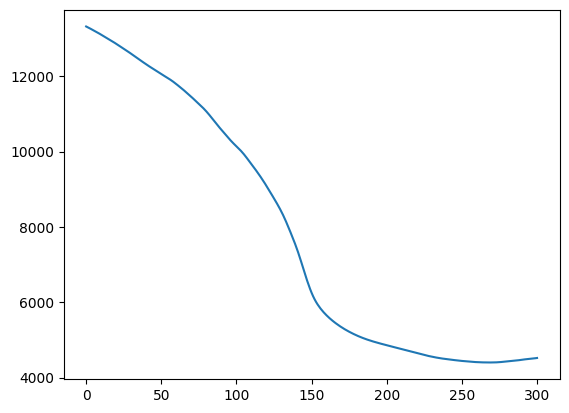

In [6]:
plt.plot(np.mean(Temp, axis=(1,2)))

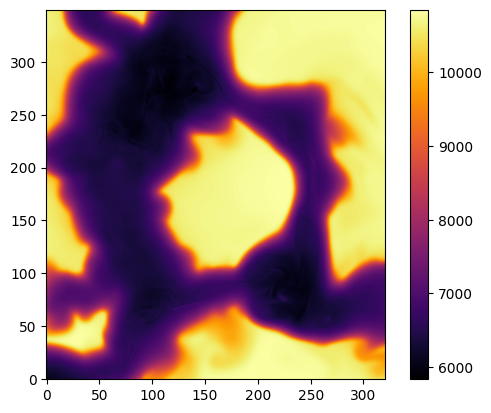

In [7]:
plt.imshow(Temp[130, :, :].T, cmap='inferno', origin='lower')
plt.colorbar()

In [8]:
# Reproduce the plot from Jan, by looping through a given set of time instances
t_start = 8840
t_end = 8860
i_start = 151
i_end = 152
j_start = 132
j_end = 133



In [10]:
final_cube = np.zeros([9, t_end-t_start, Temp.shape[0]])
final_cube.shape

(9, 20, 301)

In [62]:
for t in tqdm(range(t_start, t_end)):
    temp_cube = h5py.File(f'/dat/milic/co5bold_cg_timeseries/ROI_5/ROI_5_data_{t}s.h5')
    
    final_cube[0,t-t_start,:] = np.mean(temp_cube['T'][:,i_start:i_end, j_start:j_end], axis=(1,2))
    final_cube[1,t-t_start,:] = np.mean(temp_cube['p'][:,i_start:i_end, j_start:j_end], axis=(1,2))
    final_cube[2,t-t_start,:] = np.mean(temp_cube['rho'][:,i_start:i_end, j_start:j_end], axis=(1,2))
    final_cube[3,t-t_start,:] = np.mean(temp_cube['vx'][:,i_start:i_end, j_start:j_end], axis=(1,2))
    final_cube[4,t-t_start,:] = np.mean(temp_cube['vy'][:,i_start:i_end, j_start:j_end], axis=(1,2))
    final_cube[5,t-t_start,:] = np.mean(temp_cube['vz'][:,i_start:i_end, j_start:j_end], axis=(1,2))
    final_cube[6,t-t_start,:] = np.mean(temp_cube['bx'][:,i_start:i_end, j_start:j_end], axis=(1,2))
    final_cube[7,t-t_start,:] = np.mean(temp_cube['by'][:,i_start:i_end, j_start:j_end], axis=(1,2))
    final_cube[8,t-t_start,:] = np.mean(temp_cube['bz'][:,i_start:i_end, j_start:j_end], axis=(1,2))

  0%|          | 0/20 [00:00<?, ?it/s]

100%|██████████| 20/20 [00:21<00:00,  1.07s/it]


In [8]:
final_cube = fits.open('/dat/milic/atmos_cube_Na_wave.fits')[0].data
final_cube.shape

(9, 20, 301)

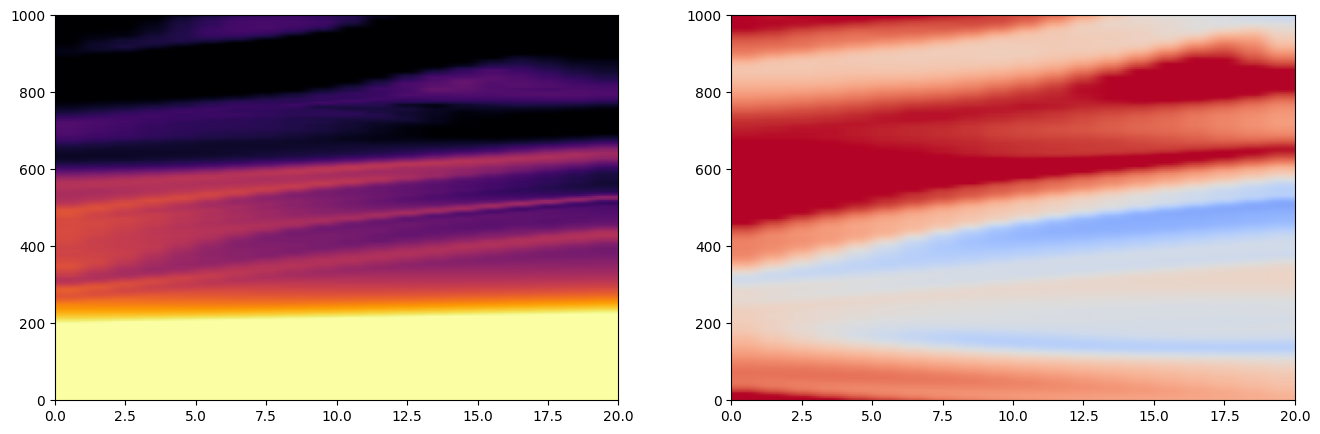

In [9]:
plt.figure(figsize=[16,5])
plt.subplot(121)
plt.imshow(final_cube[0,:,100:300].T, cmap='inferno', origin='lower', aspect='auto',vmin=4500,vmax=6000, extent=[0,20,0,1000])
plt.subplot(122)
plt.imshow(-final_cube[5,:,100:300].T/1E5, cmap='coolwarm', origin='lower', aspect='auto',vmin=-5,vmax=5, extent=[0,20,0,1000])

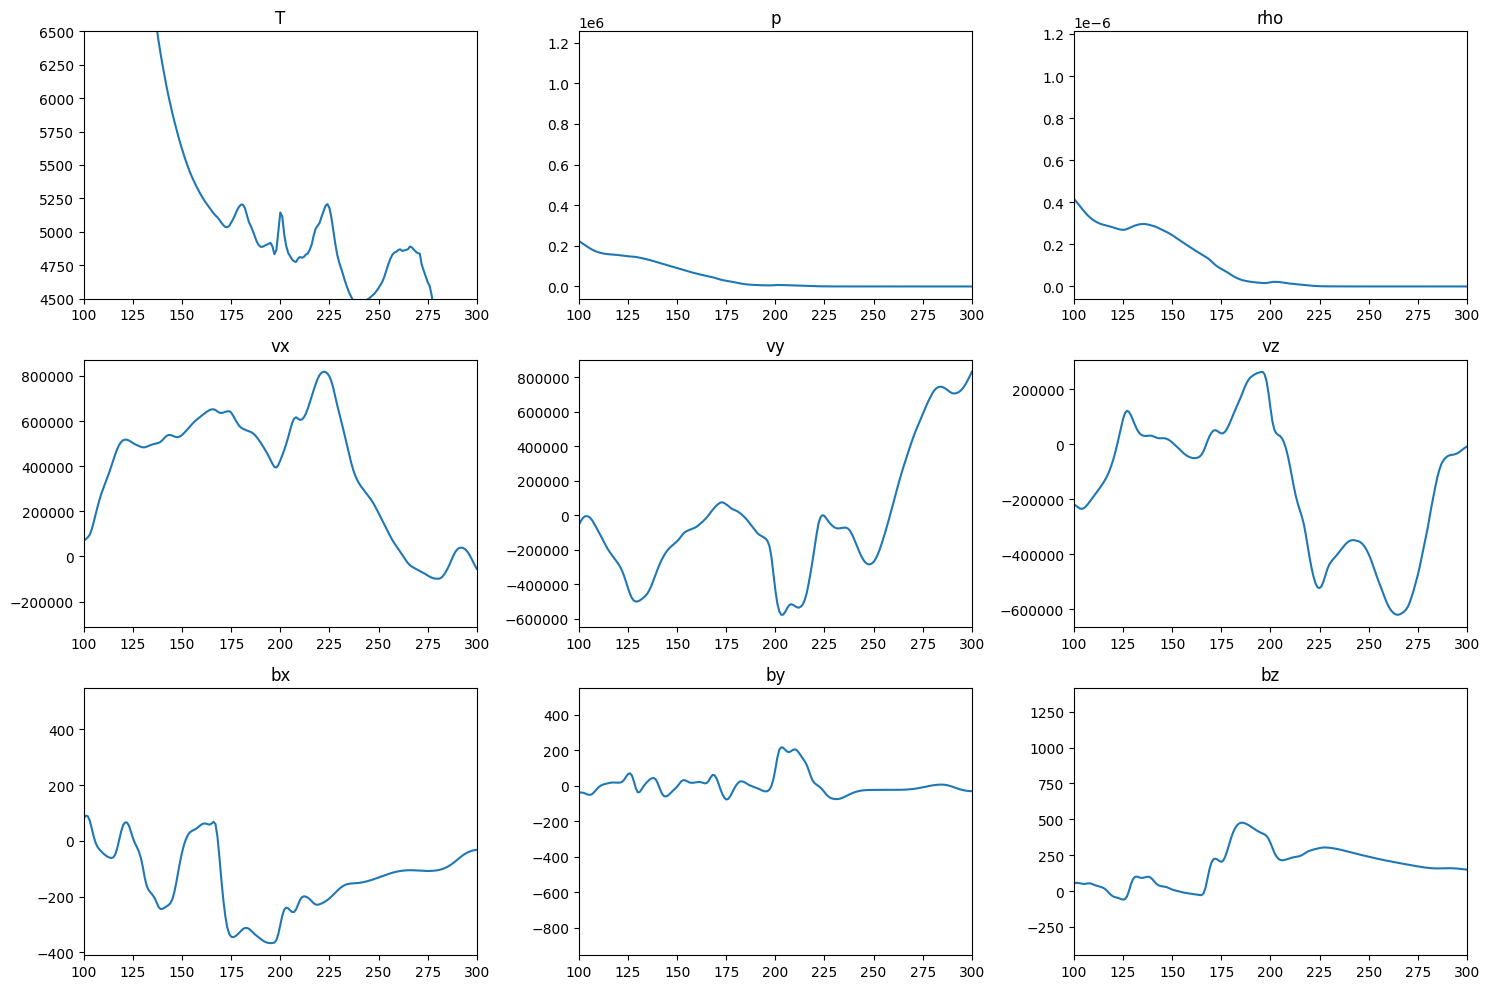

In [10]:
# I like the instance # 20 
t_wave = 15
# Multiplot with 3 rows and 3 columns
fig, axs = plt.subplots(3, 3, figsize=(15, 10))
# Plot the depth variance of each variable at the given time instance
variables = ['T', 'p', 'rho', 'vx', 'vy', 'vz', 'bx', 'by', 'bz']
for i in range(3):
    for j in range(3):
        var_index = i*3 + j
        axs[i, j].plot(final_cube[var_index, t_wave, :].T)
        axs[i, j].set_title(variables[var_index])
        axs[i, j].set_xlim([100,300])
        

axs[0,0].set_ylim([4500, 6500])
plt.tight_layout()
plt.show()

In [65]:
# Save the atmosphere cube in a fits file
kek = fits.PrimaryHDU(final_cube)
kek.writeto('/dat/milic/atmos_cube_Na_wave.fits', overwrite=True)

In [11]:
import lightweaver as lw 
ND = Temp.shape[0]
z_scale = np.arange(ND) * 5000.0 # m wave = np.linspace(588.8, 589.8, 1000) # Angstrom
lw_cube = np.ascontiguousarray(final_cube[:,:,::-1])
z_scale = np.ascontiguousarray(z_scale[::-1])

#print(z_scale)


In [12]:
from lightweaver.rh_atoms import (Al_atom, C_atom, CaII_atom, Fe_simple_atom, H_6_atom, He_9_atom, MgI_atom, N_atom, Na_atom, O_atom, S_atom, Si_atom)

In [13]:

def airtovac(lambda_air):

    s = 1E2/(lambda_air*1E8);
    n = 1.0 + 0.00008336624212083 + 0.02408926869968 / (130.1065924522 - s*s) + 0.0001599740894897 / (38.92568793293 - s*s);
    return lambda_air * n

def synth(atmos, conserve, prd, stokes, wave, mu, actives):
    
    '''
    Synthesize a spectral region with given parameters:
    
    Parameters
    ----------
    atmos : lw.Atmosphere - The atmospheric model in which to synthesise the line.
    
    conserve : bool - Whether to start from LTE electron density and conserve charge, or simply use from the electron density present in the atmospheric model.

    prd: bool - whether to use prd or no, most of the time it's no 

    stokes: bool - whether to synth all 4 Stokes parameters or I only - for tracking we start with I only
    
    wave : np.ndarray Array of wavelengths over which to resynthesise the final line profile

    mu : mu angle, gonna use 1.0 most of the times 

    actives: list of active species to synthesize

    Returns
    -------
    ctx : lw.Context -The Context object that was used to compute the equilibrium populations -> Gonna not return this
    
    Iwave : np.ndarray - The intensity at given mu and wave    '''
    
    # Configure the atmospheric angular quadrature - only matters for NLTE. Gonna use 3 for faster calc
    atmos.quadrature(3)#, force3d=True)
    # See if you can force this to 
    # Replace this with atmos.rays ( specify mu ) - let's think how to use Stokes with it
    # ctx.single_stokes_fs
    
    # Configure the set of atomic models to use. Contrary to SNAPI you have to explicitly specify all species
    # Annoying, but since you have all the atoms in the file - that is fine.
    aSet = lw.RadiativeSet([H_6_atom(), C_atom(), O_atom(), Si_atom(), Al_atom(), CaII_atom(), Fe_simple_atom(), He_9_atom(), MgI_atom(), N_atom(), Na_atom(), S_atom()])
    
    # Set actives to the ones you want
    #aSet.set_active(actives)
    aSet.set_active(actives)
    
    # Compute the necessary wavelength dependent information (SpectrumConfiguration).
    spect = aSet.compute_wavelength_grid()
    
    # Calculate electron density in lte, we are never using the electron density from the model
    eqPops = aSet.iterate_lte_ne_eq_pops(atmos, direct=True)

    # Configure the Context which holds the state of the simulation for the  backend, and provides 
    # the python interface to the backend.
    # Feel free to increase Nthreads to increase the number of threads the program will use.
    # I would always stick to Nthreads = 1 as we are looking to mpi this one
    
    ctx = lw.Context(atmos, spect, eqPops, conserveCharge=False, Nthreads=1, formalSolver='piecewise_linear_1d')
    
    # Iterate the Context to convergence (using the iteration function now
    # provided by Lightweaver). Go test this one in order to calculate stuff in LTE!
    
    #lw.iterate_ctx_se(ctx, prd=prd)
    
    # NLTE quiet
    lw.iterate_ctx_se(ctx, prd=prd, quiet=True)

    # LTE:
    #ctx.formal_sol_gamma_matrices()

    
    # Update the background populations based on the converged solution and
    # compute the final intensity for mu=1 on the provided wavelength grid.
    #eqPops.update_lte_atoms_Hmin_pops(atmos)
    
    # Calculate the (stokes) spectru, at the provided wavegrid at the specified mu
    Iwave = ctx.compute_rays(wave, [mu], stokes=stokes) 

    # We will want to return some populations or so, at some point (Firtez pipeline)
    #return ctx, Iwave

    # For now we are only returning the intensity:
    if (stokes == False):
        Iwave = Iwave.reshape(1,-1)
    
    return ctx, Iwave


def synth_final(z_scale, atmos, wave, t_wave):
    
    ND = atmos.shape[2]
    
    atmos = lw.Atmosphere.make_1d(scale=lw.ScaleType.Geometric, depthScale=z_scale[:], temperature=atmos[0, t_wave,:],  \
        vlos=atmos[3,t_wave,:]/1E2, vturb=np.ones(ND)*5E2, Pgas=atmos[1, t_wave,:]/10.0, convertScales=False)

    ctxtemp, Itemp = synth(atmos, conserve=False, prd=False, stokes=False, wave=wave_vac, mu=1.0, actives='Na')
    
    return ctxtemp, Itemp
    


In [16]:
wave = np.linspace(588.8, 589.8, 1001)
wave_vac = airtovac(wave)
wave_vac = np.ascontiguousarray(wave_vac)

In [14]:
# Bin the lw cube in 3 steps in the last coordinate to simplify the atmosphere and speed up the calculations, we are not interested in the depth variance for now, but rather in the time variance of the line profile
lw_cube_mini = lw_cube[:, :, ::3]


In [17]:
# synthesize Na line from a given atmosphere:

spec, temp = synth_final(np.ascontiguousarray(z_scale[::3]), np.ascontiguousarray(lw_cube_mini), wave_vac, t_wave)



TypingError: Failed in nopython mode pipeline (step: nopython frontend)
non-precise type pyobject
During: typing of argument at /home/milic/codes/Lightweaver/lightweaver/atomic_set.py (19)

File "../Lightweaver/lightweaver/atomic_set.py", line 19:

@njit(cache=True)
^

During: Pass nopython_type_inference 

This error may have been caused by the following argument(s):
- argument 0: Unsupported array dtype: >f8


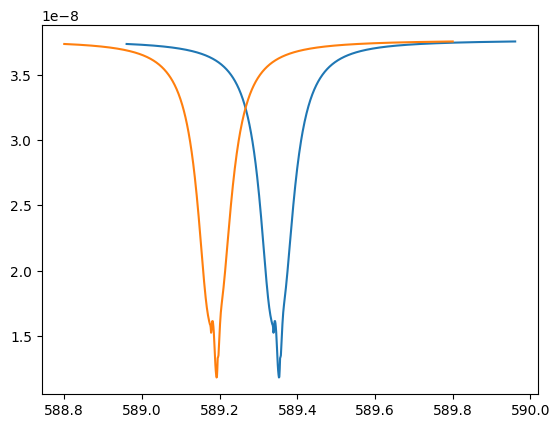

In [79]:
plt.plot(wave_vac, Itemp[0,:])
plt.plot(wave, Itemp[0,:])